<a href="https://colab.research.google.com/github/abbynam/ds201_capstone1/blob/main/Capstone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DS201 Capstone 1
#### By Abby and Lilly

In [1]:
!wget "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"

--2026-09-26 16:17:04--  https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv
Resolving www.fhfa.gov (www.fhfa.gov)... 54.92.167.213
Connecting to www.fhfa.gov (www.fhfa.gov)|54.92.167.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17154972 (16M) [text/csv]
Saving to: ‘hpi_master.csv’

hpi_master.csv      100%[===================>]  16.36M  23.2MB/s    in 0.7s    

2026-09-26 16:17:05 (23.2 MB/s) - ‘hpi_master.csv’ saved [17154972/17154972]



### 1. Understanding the Data

* When was the data acquired?

Data collection began in January 1975. It was last updated in August 2026. It is continuously collected over time, typically monthly and every housing quarter.

* Where was the data acquired?

The data was acquired from four hundred cities across all fifty states. Indexes are also included for all nine census divisions, the District of Columbia, every Metropolitan Statistical Area (MSA), and Puerto Rico.

* How was the data acquired?

The FHFA reviews repeat mortgage transactions on single-family properties handled by the Federal National Mortgage Association (Fannie Mae) and the Federal Home Loan Mortgage Corporation (Freddie Mac) to compile data for HPI reports on a monthly and quarterly basis. For the master HPI dataset, current and prior data is merged to create an updated historical database.

* What are the attributes of this dataset? / What type of data do these attributes contain?


| Attribute Name | Data Type | Description                                                                                                                               |
| -------------- | --------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| `hpi_type`     | Nominal   | Categorizes the type of HPI product: traditional, developmental, distress-free, non-metro, or manufactured.                               |
| `hpi_flavor`   | Nominal   | Categorizes how the HPI was calculated: purchase-only, all-transactions, or expanded-data.                                                |
| `frequency`    | Ordinal   | How often a given HPI was reported: monthly or quarterly.                                                                                 |
| `level`        | Nominal   | Describes where the HPI is measured: USA or Census Division, State, MSA (Metropolitan Statistical Area), or Puerto Rico.                  |
| `place_name`   | Nominal   | Name of the specific geographic region for a given HPI: Pacific Division, East North Central Division, Alabama, etc.                      |
| `place_id`     | Nominal   | Contains abbreviations for state names or Core-Based Statistical Area (CBSA) codes for geographic regions.                                |
| `yr`           | Interval  | Year HPI was measured.                                                                                                                    |
| `period`       | Interval   | Which quarter or month HPI was measured in (1–4 for quarterly, 1–12 for monthly).                                                         |
| `index_nsa`    | Interval  | Non-seasonally adjusted index. Measures raw house prices.                                                                                 |
| `index_sa`     | Interval  | Seasonally adjusted index. Adjusts house prices for seasonal patterns, such as holiday shopping spikes and winter construction slowdowns. |
| `rstderr`      | Ratio     | Repeat-sales standard error. Measures the uncertainty in HPI estimates.                                                                   |
| `note`         | Nominal   | For some observations, indicates that FHFA did not have enough sales data to estimate HPI.                                                |


### 2. Exploratory Data Analysis

* Present summary statistics for the attributes (mean, median, mode, range, standard deviation, etc.).

In [31]:
import pandas as pd
hpi = pd.read_csv('hpi_master.csv')

# summary statistics for the numeric data
summary_stats = hpi[['yr', 'index_nsa', 'index_sa', 'rstderr']].describe()

/tmp/ipykernel_1796/2767535898.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  hpi = pd.read_csv('hpi_master.csv')


In [32]:
print(summary_stats.to_markdown())

|       |          yr |   index_nsa |   index_sa |     rstderr |
|:------|------------:|------------:|-----------:|------------:|
| count | 186011      |  186011     |  96114     | 58220       |
| mean  |   2006.16   |     199.962 |    216.67  |     2.67325 |
| std   |     12.0044 |     116.125 |    113.513 |     2.22215 |
| min   |   1975      |      18.6   |     72.78  |     0       |
| 25%   |   1997      |     119.61  |    137.29  |     1.06    |
| 50%   |   2007      |     172.13  |    187.21  |     2.05    |
| 75%   |   2016      |     241.38  |    258.337 |     3.6     |
| max   |   2026      |    1326.94  |   1043.2   |    15.75    |


In [26]:
# most frequently occurring levels for each categorical attribute
categories = ['level', 'place_name', 'hpi_type', 'hpi_flavor', 'frequency']

mode = hpi[categories].mode()

In [27]:
print(mode.to_markdown())

|    | level   | place_name    | hpi_type    | hpi_flavor       | frequency   |
|---:|:--------|:--------------|:------------|:-----------------|:------------|
|  0 | MSA     | United States | traditional | all-transactions | quarterly   |


In [34]:
# frequency table for period

period_counts = hpi.groupby('frequency')['period'].value_counts().sort_index()
period_counts

frequency  period
monthly    1           360
           2           360
           3           360
           4           360
           5           360
           6           360
           7           350
           8           350
           9           350
           10          350
           11          350
           12          350
quarterly  1         45844
           2         45977
           3         44931
           4         44999
Name: count, dtype: int64

In [35]:
print(period_counts.to_markdown())

|                  |   count |
|:-----------------|--------:|
| ('monthly', 1)   |     360 |
| ('monthly', 2)   |     360 |
| ('monthly', 3)   |     360 |
| ('monthly', 4)   |     360 |
| ('monthly', 5)   |     360 |
| ('monthly', 6)   |     360 |
| ('monthly', 7)   |     350 |
| ('monthly', 8)   |     350 |
| ('monthly', 9)   |     350 |
| ('monthly', 10)  |     350 |
| ('monthly', 11)  |     350 |
| ('monthly', 12)  |     350 |
| ('quarterly', 1) |   45844 |
| ('quarterly', 2) |   45977 |
| ('quarterly', 3) |   44931 |
| ('quarterly', 4) |   44999 |


* Identify any missing (NA) or empty values and discuss potential strategies to handle them.


In [39]:
# find missing values in every column
missing = hpi.isna().sum()
missing

,0
hpi_type,0
hpi_flavor,0
frequency,0
level,0
place_name,0
place_id,0
yr,0
period,0
index_nsa,0
index_sa,89897


In [38]:
print(missing.to_markdown())

|            |      0 |
|:-----------|-------:|
| hpi_type   |      0 |
| hpi_flavor |      0 |
| frequency  |      0 |
| level      |      0 |
| place_name |      0 |
| place_id   |      0 |
| yr         |      0 |
| period     |      0 |
| index_nsa  |      0 |
| index_sa   |  89897 |
| rstderr    | 127791 |
| note       | 127791 |


One strategy to handle the missing values (marked as NaN in pandas) is to drop all the rows with empty values (using hpi.dropna()). This is simple and keeps only the rows with fully complete data, but because there are 89,897 missing values for column index_sa and 127,791 missing values for columns rstderr and note, we would be throwing away nearly all of the data.

Another solution is to drop the columns that have the most missing values. For example, the column called note. This may be more reasonable because note only has values for a few rows, minimizing how much data gets dropped from the dataset.

A final option could be filling in the missing values for index_sa with the mean or median of the column. While this would retain the most data for analysis, it would also flatten the natural variation in the data that misleadingly makes the data look more uniform than actually is. Additionally, the majority of seasonally-adjusted HPIs are calculated for state HPIs. Using the mean and median from seasonally-adjusted state HPIs may then wrongly assume that a house from USA or Census Division level will have a similar seasonally-adjusted HPI.

### Figure 1: Bar charts of categorical variable counts

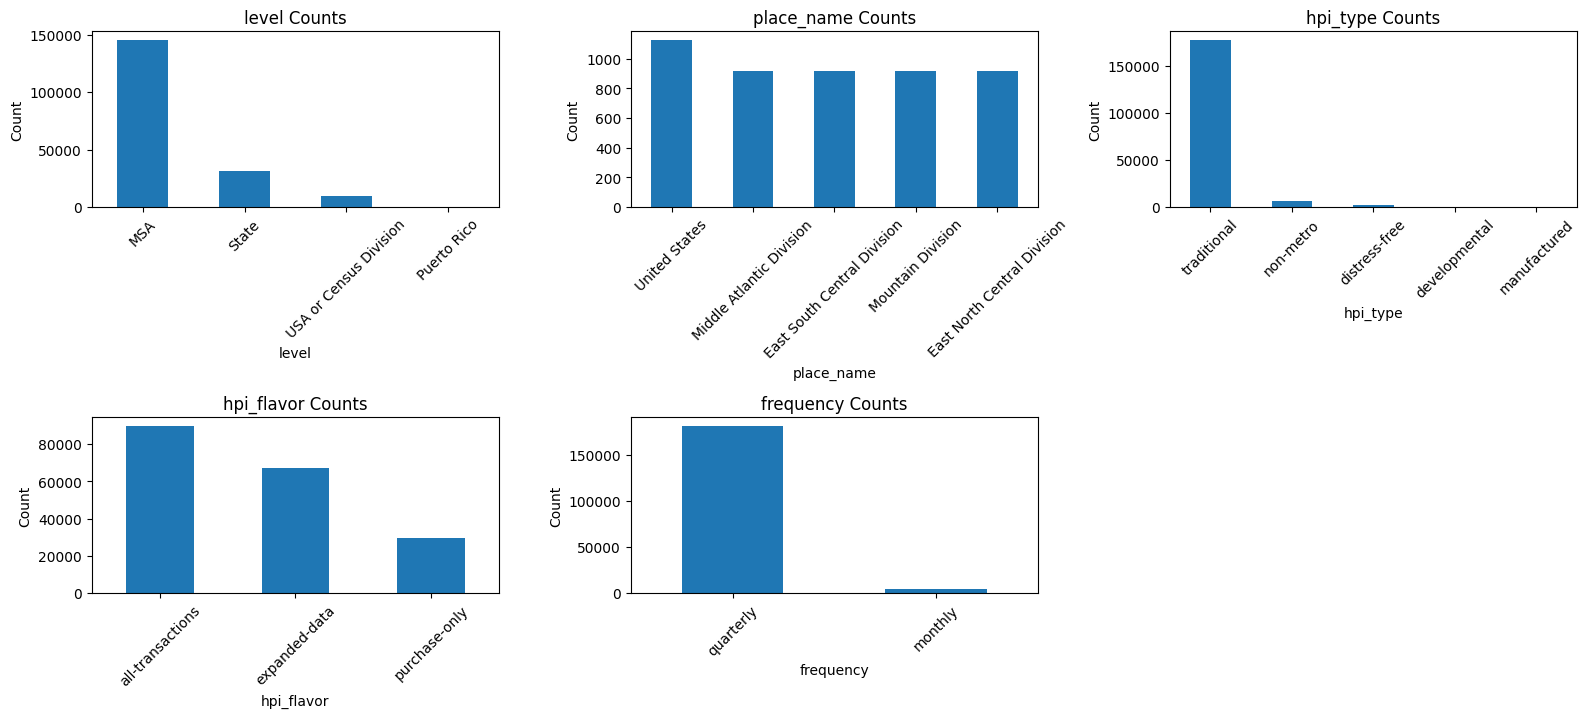

<Figure size 640x480 with 0 Axes>

In [40]:
# categorical variable counts
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for ax, col in zip(axes.flat, categories):
    counts = hpi[col].value_counts()

    # Restrict place_name to only the top 5
    if col == 'place_name':
        counts = counts.head(5)

    # Sort period numerically
    if col == 'period':
        counts = counts.sort_index()

    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} Counts')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

# Hide the 3 unused subplots
for ax in axes.flat[len(categories):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

These visualizations are consistent with the calculation of the mode. Note that Puerto Rico and many of the numbers corresponding to monthly periods do not show up on the graph due to the y-axis intervals, but values for these levels do exist:

In [7]:
hpi['place_name'].value_counts()['Puerto Rico']

np.int64(247)

In [8]:
hpi['period'].value_counts()

,count
period,
2,46337
1,46204
4,45359
3,45291
5,360
6,360
7,350
8,350
9,350


###Figure 2: Histograms of numeric attributes

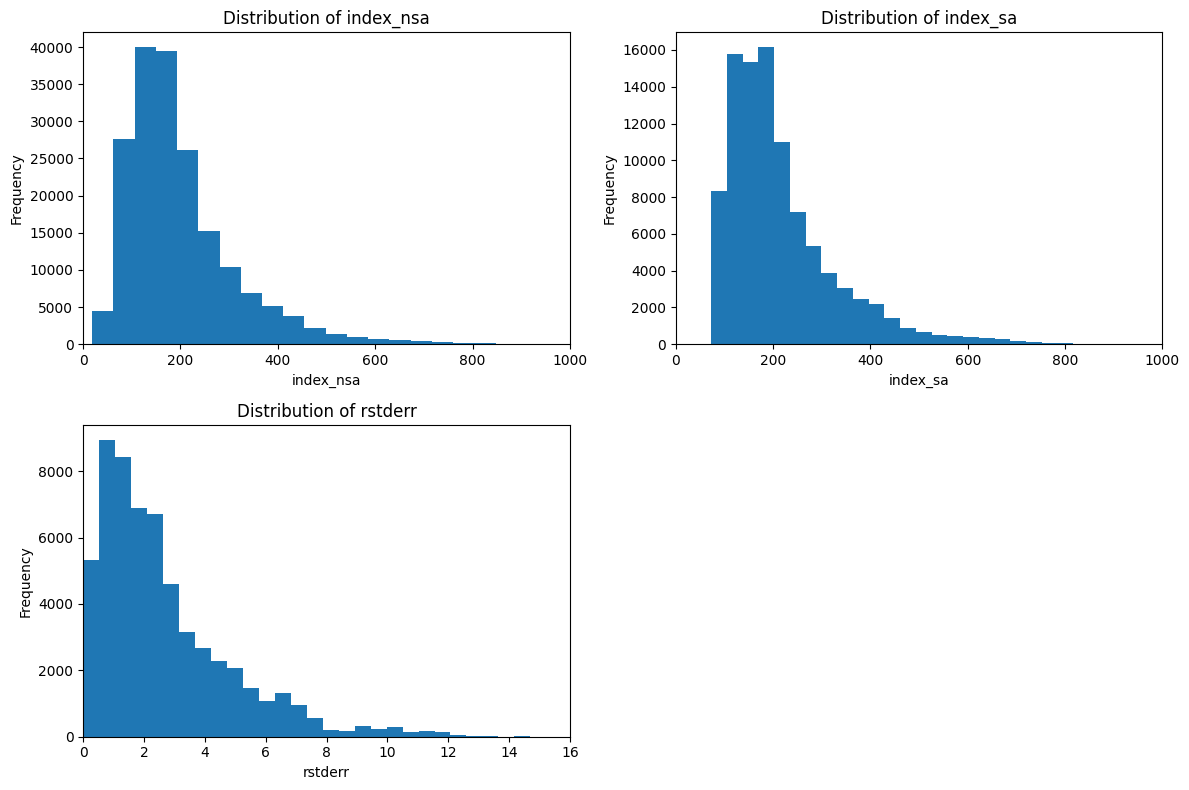

In [9]:
# histograms for distribution of numeric attributes
numeric = ['index_nsa', 'index_sa', 'rstderr']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x_ranges = {
    'index_nsa': (0, 1000),
    'index_sa': (0, 1000),
    'rstderr': (0, 16)
}

for ax, col in zip(axes.flat, numeric):
    hpi[col].plot(kind='hist', bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_xlim(x_ranges[col])

# Hide the 1 unused subplot
for ax in axes.flat[len(numeric):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The three numeric attributes are positively skewed.

###Figure 3: Boxplots of non-seasonally adjusted HPI, by HPI type

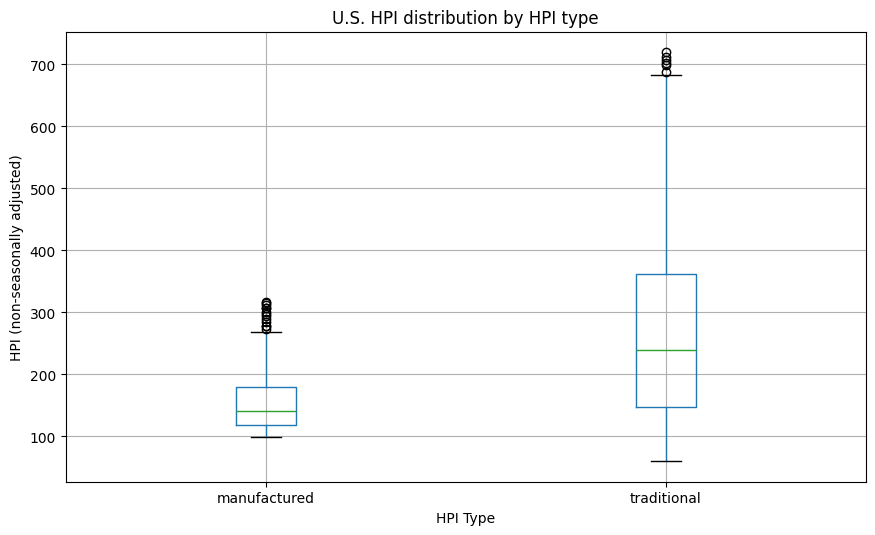

In [42]:
# boxplots to indicate outliers

fig3 = hpi[
    (hpi['place_name'] == 'United States') &
    (hpi['frequency'] == 'quarterly') &
    (hpi['hpi_flavor'] == 'all-transactions')
]

fig3.boxplot(column='index_nsa', by='hpi_type', figsize=(10, 6))

plt.title('U.S. HPI distribution by HPI type')
plt.suptitle('')
plt.xlabel('HPI Type')
plt.ylabel('HPI (non-seasonally adjusted)')

plt.show()

The distribution of traditional HPIs is more spread out than manufactured HPIs for this dataset. There are several observations for both U.S. HPI types beyond the upper whiskers, which could indicate potential outliers. Compared to the traditional HPIs, the manufactured HPIs are more clustered together.

### Figure 4: Line graph for U.S. traditional all-transactions non-seasonally adjusted quarterly HPI over time

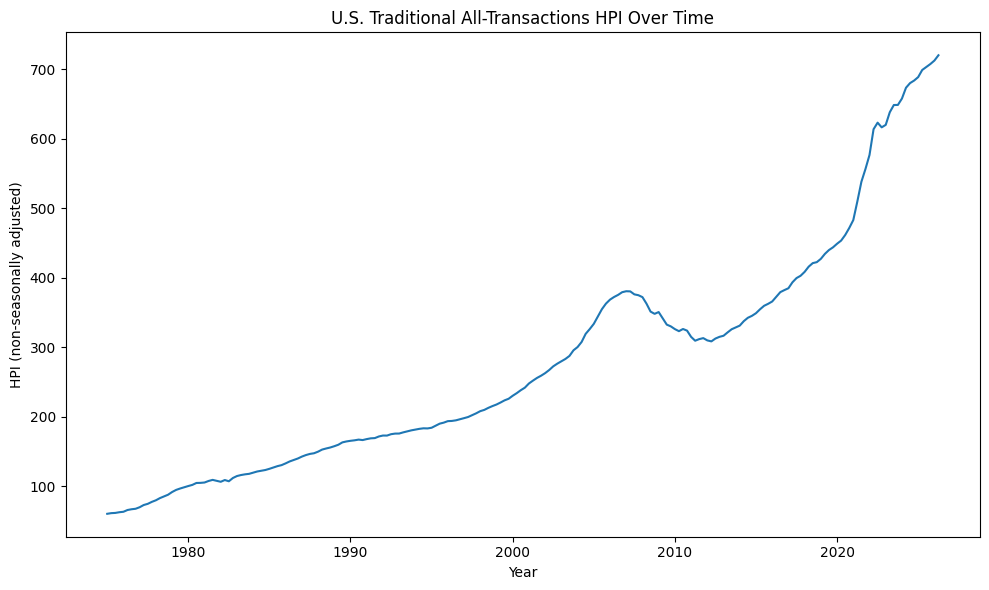

In [44]:
# scatterplot for year vs. index_nsa
usa_hpi = hpi[
    (hpi['place_name'] == 'United States') &
    (hpi['hpi_type'] == 'traditional') &
    (hpi['hpi_flavor'] == 'all-transactions') &
    (hpi['frequency'] == 'quarterly')
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    usa_hpi['yr'] + (usa_hpi['period'] - 1) / 4,
    usa_hpi['index_nsa']
)

plt.title('U.S. Traditional All-Transactions Quarterly HPI Over Time')
plt.xlabel('Year')
plt.ylabel('HPI (non-seasonally adjusted)')

plt.tight_layout()
plt.show()

Based on this visualization showing the changes in this specific subset of HPIs over time, the U.S. traditional, all-transactions, quarterly HPIs have generally increased since 1975. There is a dip beginning around 2007-2009, and more rapid growth that begins around 2019-2020. Non-seasonally adjusted HPI was chosen because it provides more observations in the dataset than seasonally adjusted HPI values, which contain substantially more missing data and are primarily available for state-level HPIs only.

### 3. Expanding Investment Knowledge
* Why would this dataset be useful?

This dataset would be useful because it provides more detailed information about historical trends in real estate on the state level and compares a given listing to other listings in the region. For instance, average_listing_price_yy provides the percent change in average listing price from the same month in the previous year.

* How could it complement the data you are currently analyzing?

This dataset could complement the FHFA HPI dataset by providing more context for a particular state’s average HPI, including how long listings stay up and insights on average listing counts and prices throughout a certain state. This additional information could also be used to better understand and compare patterns in HPI between states.

* Provide a link to the additional dataset.

https://econdata.s3-us-west-2.amazonaws.com/Reports/Core/RDC_Inventory_Core_Metrics_State_History.csv

Overall, U.S. traditional all-transactions non-seasonally adjusted quarterly HPI increased since 1975. This trend is visualized in Fig. 4, with some sudden changes likely reflecting economic fluctuations in the U.S. For example, in Fig. 4 there is a noticeable decline around 2007-2009 and a period of rapid growth that begins around 2019-2020. These periods coincide, respectively, with the financial crisis and recession of 2008 and the COVID-19 pandemic, but cannot be said to be the causes of the changes in the graph.

Fig. 2 shows that the numeric variables have positively skewed distributions. Because the full dataset contains observations from multiple geographic levels, HPI types, flavors, and reporting frequencies, Figure 2 should be interpreted as showing the distribution of HPI observations rather than the distribution of individual home prices.